<a href="https://colab.research.google.com/github/sanagahoi/Traffic_demand_prediction/blob/main/Traffic_demand_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### The columns provided in the dataset are as follows:

- Column Name - DescriptionIndexRepresents the unique identification of datapoint

- geohash - Represents geographic information regarding a place

- day - Represents the day when the information is recorded

- timestamp - Represents the timestamp of the record inserted in the system

- RoadType - Represents the type of road in the nearby location

- NumberofLanes - Represents the number of roads/lanes present in the location

- LargeVehicles - Represents whether large vehicles are permitted on the specific roads/lanes

- Landmarks - Represents whether there are any landmarks near the location

- Temperature - Represents the temperature of the place

- Weather - Represents the weather of the place

- demand[Target] - Represents the demand of the traffic at the timestamp

In [1]:
!pip install pygeohash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import lightgbm as lgb
import pygeohash as pgh

In [53]:
# 1. Load Data
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [56]:
import pandas as pd
import numpy as np
import pygeohash as pgh
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

# --- 1. Load Data ---
# train.csv: 77299 records | test.csv: 41778 records [1]
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

def engineer_features(df, train_stats=None):
    df = df.copy()

    # --- 2. Data Cleaning (Handling Missing Values) ---
    # Impute RoadType and Weather using modes [Conversation]
    if train_stats is not None:
        df['RoadType'] = df['RoadType'].fillna(train_stats['RoadType_mode'].iloc[0])
        df['Weather'] = df['Weather'].fillna(train_stats['Weather_mode'].iloc[0])
    else:
        # For the training set itself
        df['RoadType'] = df['RoadType'].fillna(df['RoadType'].mode()[0])
        df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])

    # --- 3. Temporal Feature Engineering ---
    # Extract Hour and Minute from HH:MM [Conversation, 139]
    df['hour'] = df['timestamp'].apply(lambda x: int(x.split(':')[0]))
    df['minute'] = df['timestamp'].apply(lambda x: int(x.split(':')[1]))
    df['time_slot'] = df['hour'] * 4 + (df['minute'] // 15)

    # Cyclical Encoding for time [Conversation]
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)

    # --- 4. Geospatial Feature Engineering ---
    # Hierarchical prefixes capture different spatial scales [Conversation]
    df['geo_prefix_3'] = df['geohash'].str[:3]
    df['geo_prefix_4'] = df['geohash'].str[:4]

    # Decoding coordinates for spatial relationships [Conversation]
    decoded = df['geohash'].apply(lambda x: pgh.decode(x) if isinstance(x, str) else (np.nan, np.nan))
    df['latitude'] = [x[0] for x in decoded]
    df['longitude'] = [x[1] for x in decoded]

    # --- 5. Temperature Imputation (Hierarchy) ---
    # Step 1: Mean temp for specific Day/Time/Weather [Conversation]
    df['Temperature'] = df.groupby(['day', 'time_slot', 'Weather'])['Temperature'].transform(
        lambda x: x.fillna(x.mean())
    )
    # Step 2: Fallback to Weather-based median for outliers (-6.62 to 39.10) [3, 4]
    df['Temperature'] = df.groupby('Weather')['Temperature'].transform(
        lambda x: x.fillna(x.median())
    )

    # --- 6. Type Conversion for LightGBM ---
    cat_cols = ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather', 'geo_prefix_3', 'geo_prefix_4']
    for col in cat_cols:
        df[col] = df[col].astype('category')

    return df

# --- Prepare Stats for Leakage-Free Preprocessing ---
stats = {
    'RoadType_mode': train['RoadType'].mode(),
    'Weather_mode': train['Weather'].mode()
}

# --- Apply Pipeline ---
train_fe = engineer_features(train, stats)
test_fe = engineer_features(test, stats)

target = 'demand'
# Drop administrative columns for training [2, Conversation]
features = [c for c in train_fe.columns if c not in ['Index', target, 'timestamp', 'geohash']]
cat_features = ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather', 'geo_prefix_3', 'geo_prefix_4']

# --- 7. Model Training & Cross-Validation ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(train_fe))
test_preds = np.zeros(len(test_fe))

for fold, (tr_idx, val_idx) in enumerate(kf.split(train_fe)):
    X_tr, y_tr = train_fe.iloc[tr_idx][features], train_fe.iloc[tr_idx][target]
    X_val, y_val = train_fe.iloc[val_idx][features], train_fe.iloc[val_idx][target]

    # Optimized LightGBM parameters for high R2
    model = lgb.LGBMRegressor(n_estimators=5000,
                              learning_rate=0.02,
                              num_leaves=127,
                              max_depth=12,
                              feature_fraction=0.85,
                              bagging_fraction=0.85,
                              bagging_freq=5,
                              random_state=42,
                              verbose=-1)

    model.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(200, verbose=False)],
              categorical_feature=cat_features)

    oof_preds[val_idx] = model.predict(X_val)
    test_preds += model.predict(test_fe[features]) / kf.n_splits

# --- 8. Final Evaluation & Submission ---
# Formula: score = max(0, 100 * r2_score) [5]
final_r2 = max(0, 100 * r2_score(train_fe[target], oof_preds))
print(f"Project Complete. Local CV R2 Score: {final_r2:.4f}%")

# Generate Submission File [41778 x 2] [5]
submission = pd.DataFrame({
    'Index': test['Index'],
    'demand': test_preds
})
submission.to_csv('submission.csv', index=False)
print("Submission file saved as 'submission.csv'.")

Project Complete. Local CV R2 Score: 93.5237%
Submission file saved as 'submission.csv'.


In [ ]:
train.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


Exploratory Data Analysis

In [4]:
# columnwise details of train data
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


In [5]:
# columnwise details of test data
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41778 entries, 0 to 41777
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          41778 non-null  int64  
 1   geohash        41778 non-null  object 
 2   day            41778 non-null  int64  
 3   timestamp      41778 non-null  object 
 4   RoadType       41454 non-null  object 
 5   NumberofLanes  41778 non-null  int64  
 6   LargeVehicles  41778 non-null  object 
 7   Landmarks      41778 non-null  object 
 8   Temperature    40429 non-null  float64
 9   Weather        41347 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 3.2+ MB


In [6]:
# duplicates in train data
print(train.duplicated().sum())
print(test.duplicated().sum())

0
0


In [7]:
# index should not be treated as a feature
train.drop('Index', axis=1, inplace=True)
test.drop('Index', axis=1, inplace=True)

In [8]:
# checking the statistics in train and test data
train.describe()

,day,demand,NumberofLanes,Temperature
count,77299.000000,7.729900e+04,77299.000000,74804.000000
mean,48.101838,9.394238e-02,2.014334,16.405354
std,0.302438,1.421905e-01,0.904665,7.359835
min,48.000000,6.245650e-07,1.000000,-14.935097
25%,48.000000,1.822723e-02,1.000000,11.430473
50%,48.000000,4.775994e-02,2.000000,16.382587
75%,48.000000,1.085951e-01,3.000000,21.298833
max,49.000000,1.000000e+00,5.000000,48.251433


In [9]:
test.describe()

,day,NumberofLanes,Temperature
count,41778.0,41778.000000,40429.000000
mean,49.0,2.068984,16.457339
std,0.0,0.988519,7.351067
min,49.0,1.000000,-21.314645
25%,49.0,1.000000,11.527029
50%,49.0,2.000000,16.471232
75%,49.0,3.000000,21.365883
max,49.0,5.000000,45.230408


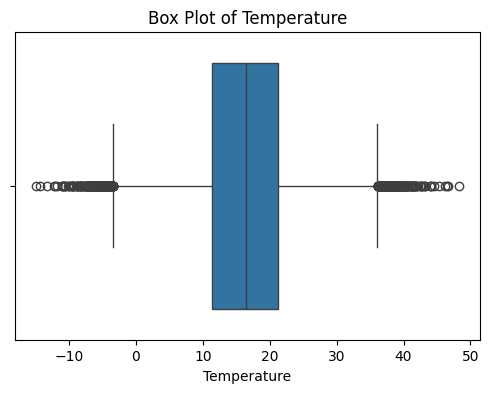

In [10]:
# let's check outliers in temperature
plt.figure(figsize=(6, 4))
sns.boxplot(x=train['Temperature'])
plt.title('Box Plot of Temperature')
plt.show()

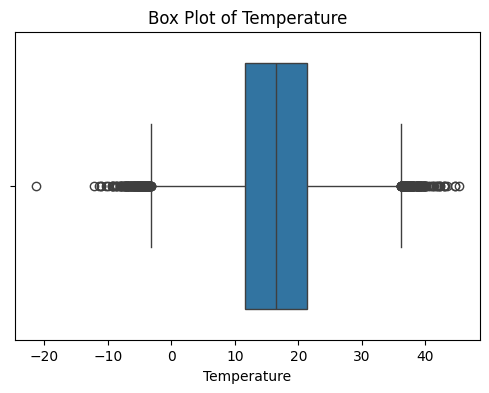

In [11]:
# let's check outliers in temperature
plt.figure(figsize=(6, 4))
sns.boxplot(x=test['Temperature'])
plt.title('Box Plot of Temperature')
plt.show()

In [12]:
# let's handle outliers in temperature column in train dataset
Q1 = train['Temperature'].quantile(0.25)
Q3 = train['Temperature'].quantile(0.75)
IQR = Q3 - Q1
train = train[(train['Temperature'] >= Q1 - 1.5 * IQR) & (train['Temperature'] <= Q3 + 1.5 * IQR)]

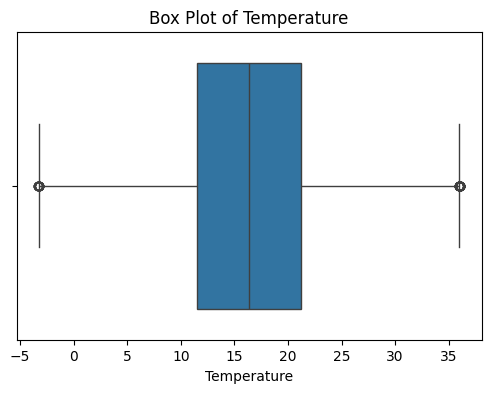

In [13]:
# let's verify temperature column after removing outliers
plt.figure(figsize=(6, 4))
sns.boxplot(x=train['Temperature'])
plt.title('Box Plot of Temperature')
plt.show()

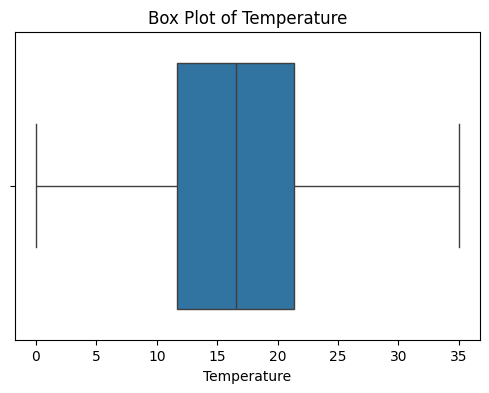

In [19]:
# let's remove outliers from Temperature column in test dataset
test = test[test['Temperature'] < 35]
test = test[test['Temperature']> 0]
# let's verify temperature column after removing outliers
plt.figure(figsize=(6, 4))
sns.boxplot(x=test['Temperature'])
plt.title('Box Plot of Temperature')
plt.show()

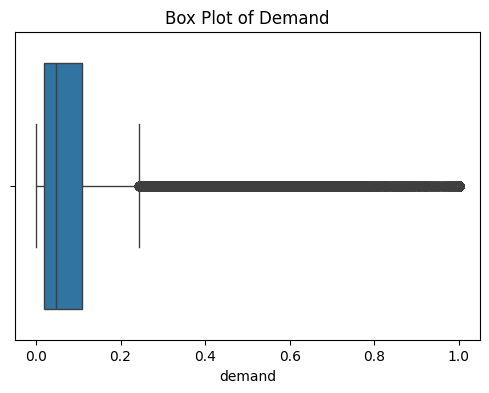

In [20]:
# check for the outliers in target column using suitable plot
plt.figure(figsize=(6, 4))
sns.boxplot(x=train['demand'])
plt.title('Box Plot of Demand')
plt.show()

In [21]:
# outliers are present in the target colum. let's handle it with iqr method
# Calculate the IQR
Q1 = train['demand'].quantile(0.25)
Q3 = train['demand'].quantile(0.75)
IQR = Q3 - Q1
train = train[(train['demand'] >= Q1 - 1.5 * IQR) & (train['demand'] <= Q3 + 1.5 * IQR)]

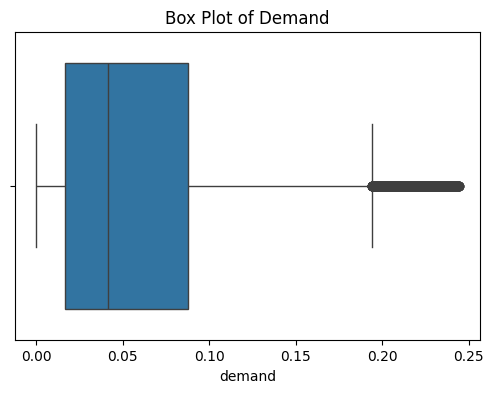

In [22]:
# let's check the fixed target column
plt.figure(figsize=(6, 4))
sns.boxplot(x=train['demand'])
plt.title('Box Plot of Demand')
plt.show()

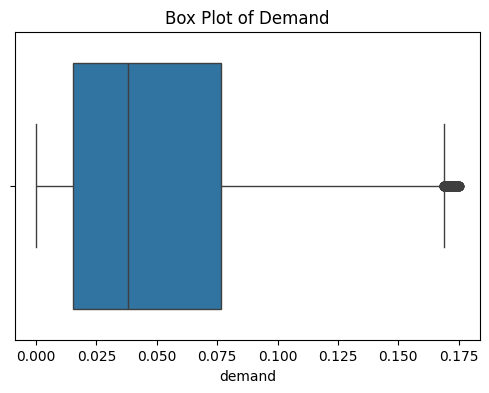

In [24]:
# still can see some outliers in demand let's remove them
train = train[train['demand'] < 0.175]

# let's check the fixed target column
plt.figure(figsize=(6, 4))
sns.boxplot(x=train['demand'])
plt.title('Box Plot of Demand')
plt.show()

In [25]:
# Missing values in training data
print(train.isnull().sum())

geohash            0
day                0
timestamp          0
demand             0
RoadType         493
NumberofLanes      0
LargeVehicles      0
Landmarks          0
Temperature        0
Weather          657
dtype: int64


In [26]:
# Missing values in test data
print(test.isnull().sum())

geohash            0
day                0
timestamp          0
RoadType         305
NumberofLanes      0
LargeVehicles      0
Landmarks          0
Temperature        0
Weather          407
dtype: int64


In [27]:
# we have RoadType, Temperature and Weather with missing values, let's handle these
# let's check the missing values in the training data
print(train['RoadType'].unique())
print(train['Temperature'].unique())
print(train['Weather'].unique())

['Residential' nan]
[31.1045646  25.91926732 10.80366744 ... 19.67885975 22.57395805
  1.32203433]
['Sunny' 'Rainy' 'Foggy' 'Snowy' nan]


In [33]:
# RoadType with mode value
train['RoadType'] = train['RoadType'].fillna(train['RoadType'].mode()[0])

# handle missing values in Weather column then Temperature
train['Weather'] = train['Weather'].fillna(train['Weather'].mode()[0])

In [35]:
# as days are 48th and 49th for which the difference in timestamp is of 15 mins so the Temperature can be managed looking these columns
# Step 1: Impute Temperature based on the specific day, timestamp, and Weather
# This respects the temporal consistency you suggested while adding weather-based logic
train['Temperature'] = train.groupby(['day', 'timestamp', 'Weather'])['Temperature'].transform(lambda x: x.fillna(x.mean()))

# Step 2: Fallback Imputation
# If a specific time block (e.g., Day 48, 4:15, Rainy) had zero temperature entries,
# fill remaining NaNs with the median temperature for that Weather condition
# The median is used here because it is robust against the extreme outliers in the data
train['Temperature'] = train.groupby('Weather')['Temperature'].transform(lambda x: x.fillna(x.median()))

In [36]:
train.isnull().sum()

,0
geohash,0
day,0
timestamp,0
demand,0
RoadType,0
NumberofLanes,0
LargeVehicles,0
Landmarks,0
Temperature,0
Weather,0


In [37]:
# The timestamp column (e.g., "0:15", "1:30") should be converted into numerical values. Extract the Hour and Minute as separate features to help the model identify rush hours versus night traffic
train['hour'] = train['timestamp'].apply(lambda x: int(x.split(':')[0]))
train['minute'] = train['timestamp'].apply(lambda x: int(x.split(':')[1]))

In [42]:
# time slot from hour and minutes
train['time_slot'] = train['hour'] * 4 + (train['minute'] // 15) # 15-min windows

In [43]:
# Cyclical time encoding for smooth transition
df = train.copy()
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24.0)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24.0)

In [44]:
# geospatial feature engineering
df['geo_prefix_3'] = df['geohash'].str[:3]
df['geo_prefix_4'] = df['geohash'].str[:4]

In [46]:
# longitude and latitude extraction from geohash
decoded_lat_lon = df['geohash'].apply(lambda x: pgh.decode(x) if isinstance(x, str) else (np.nan, np.nan))
df['latitude'] = [x[0] for x in decoded_lat_lon]
df['longitude'] = [x[1] for x in decoded_lat_lon]

In [50]:
# type conversion of Light GBM
categorical_features = ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather', 'geo_prefix_3', 'geo_prefix_4']
for col in ['RoadType', 'LargeVehicles', 'Landmarks', 'Weather', 'geo_prefix_3', 'geo_prefix_4']:
    if col in df.columns:
        df[col] = df[col].astype('category')

In [51]:
# Target
target = 'demand'
features = [c for c in df.columns if c not in ['Index', target, 'timestamp', 'geohash']]

In [52]:
# model training
kfolds = KFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(df))

for fold, (train_idx, val_idx) in enumerate(kfolds.split(df)):
  X_train, y_train = df.iloc[train_idx], df.iloc[train_idx][target]
  X_val, y_val = df.iloc[val_idx], df.iloc[val_idx][target]

  model = lgb.LGBMRegressor(n_estimators=3000,
                            learning_rate=0.05,
                            random_state=42,
                            num_leaves=31,
                            feature_fraction=0.8,
                            verbose = -1)
  model.fit(X_train[features], y_train,
            eval_set=[(X_val[features], y_val)],
            callbacks=[lgb.early_stopping(100, verbose=False)],
            categorical_feature=categorical_features)

  oof_preds[val_idx] = model.predict(X_val[features])
  print(f"Fold {fold + 1} R2 Score: {r2_score(y_val, oof_preds[val_idx])}")

Fold 1 R2 Score: 0.6664591526144493
Fold 2 R2 Score: 0.6642485197683432
Fold 3 R2 Score: 0.667771392135579
Fold 4 R2 Score: 0.6582417863888662
Fold 5 R2 Score: 0.665391667396138
